# Part 1: Simple Convolutional Neural Network

In [ ]:
import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Transformations: Resize to 32x32 and normalize
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.3403, 0.3121, 0.3214), (0.2724, 0.2608, 0.2669))
])

# Download and Load
full_train_dataset = datasets.GTSRB(root='./data', split='train', download=True, transform=transform)

# Split into Train (80%) and Validation (20%)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_data, val_data = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

test_dataset = datasets.GTSRB(root='./data', split='test', download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 187M/187M [00:09<00:00, 18.8MB/s]
100%|██████████| 89.0M/89.0M [00:05<00:00, 17.5MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 224kB/s]


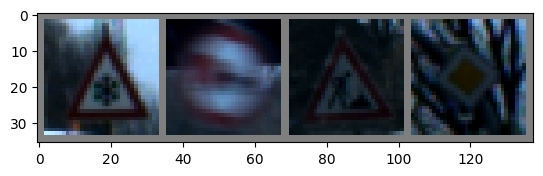

In [ ]:
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:4]))

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error

def calculate_metrics(y_true, y_pred, is_classification=True):
    """
    Outputs a dictionary of relevant ML metrics.
    y_true: Ground truth labels (numpy array)
    y_pred: Predicted labels or values (numpy array)
    """
    metrics = {}

    if is_classification:
        # For multi-class (like GTSRB), we use 'macro' or 'weighted' averaging
        metrics['Accuracy'] = accuracy_score(y_true, y_pred)
        metrics['Precision'] = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        metrics['Recall'] = recall_score(y_true, y_pred, average='weighted')
        metrics['F1-Score'] = f1_score(y_true, y_pred, average='weighted')
    else:
        # Regression metrics for AEs/GANs
        metrics['MSE'] = mean_squared_error(y_true, y_pred)
        metrics['RMSE'] = np.sqrt(metrics['MSE'])

    return metrics

In [ ]:
def plot_history(losses, accuracies):
    fig, ax1 = plt.subplots(1)

    # Plot Loss
    ax1.plot(losses, label='Training Loss', color='red')
    ax1.plot(accuracies, label='Validation Accuracy', color='blue')
    ax1.set_title('Loss Over Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    plt.show()

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class TrafficSignNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 3 input channels (RGB), 32 filters, 3x3 kernel
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) # Reduces 32x32 to 16x16
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        # Second pool reduces 16x16 to 8x8

        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 43) # 43 output classes, Final dense layer

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = TrafficSignNet().to('cuda' if torch.cuda.is_available() else 'cpu')

# Details

The first layer extracts small features though a 3x3 kernel. This detects edges and color gradients. We downsample the feature size from 32x32 to 16x16 through the pooling layer which helps the model understand the image even if the sign is slightly off center. We emphasize these feature with the 3rd layer, a convolutional layer. This layer extracts high level features such as shapes and symbols from the downsampled maps. We finalize by mapping the features with 2 linear layers that act as classifiers for the 43 traffic sign categories.

In [ ]:
import torch.optim as optim

# Setup Device, Loss, and Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_history = []
accuracy_history = []

# Training Loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_total = 0
    total_samples = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad() # Reset gradients
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass & Optimize
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        # accumulate predictions
        predictions = outputs.argmax(dim=1)
        correct_total += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    # accuracy
    epoch_acc = correct_total / total_samples

    # store results
    loss_history.append(running_loss / len(train_loader))
    accuracy_history.append(epoch_acc)

    # print results
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")
    print(f"Epoch {epoch+1}, Accuracy: {epoch_acc:.4f}")

Epoch 1, Loss: 1.0217
Epoch 1, Accuracy: 0.7125
Epoch 2, Loss: 0.1229
Epoch 2, Accuracy: 0.9666
Epoch 3, Loss: 0.0537
Epoch 3, Accuracy: 0.9851
Epoch 4, Loss: 0.0341
Epoch 4, Accuracy: 0.9909
Epoch 5, Loss: 0.0186
Epoch 5, Accuracy: 0.9949
Epoch 6, Loss: 0.0307
Epoch 6, Accuracy: 0.9919
Epoch 7, Loss: 0.0180
Epoch 7, Accuracy: 0.9954
Epoch 8, Loss: 0.0128
Epoch 8, Accuracy: 0.9965
Epoch 9, Loss: 0.0135
Epoch 9, Accuracy: 0.9964
Epoch 10, Loss: 0.0175
Epoch 10, Accuracy: 0.9945


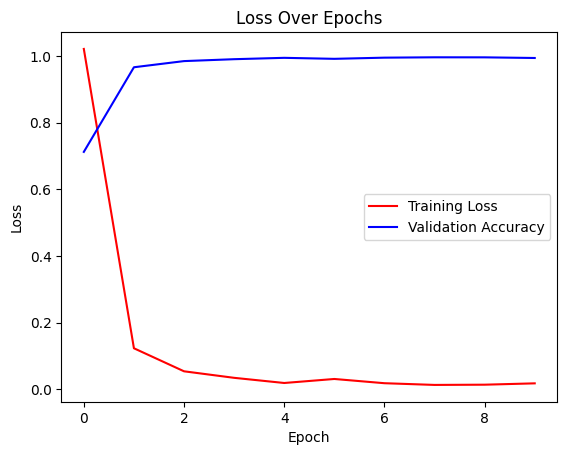

In [ ]:
plot_history(loss_history, accuracy_history)

In [ ]:
model.eval()
test_labels = []
test_preds = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        test_labels.append(labels.cpu())
        test_preds.append(predicted.cpu())

# Concatenate results
y_test_true = torch.cat(test_labels).numpy()
y_test_pred = torch.cat(test_preds).numpy()

# Generate and display the final report
test_report = calculate_metrics(y_test_true, y_test_pred, is_classification=True)
test_df = pd.DataFrame([test_report])
test_df.insert(0, "Dataset", "Official Test Set")

print(test_df)

             Dataset  Accuracy  Precision   Recall  F1-Score
0  Official Test Set   0.89715   0.908351  0.89715  0.896054


# Results


The model was tested on the German Traffic Sign Recognition Benchmark (GTSRB)and starts at around 70% accuracy but quickly rises to around 95% and higher on the training data.

On the test set we get the following metrics:\
**Accuracy (90.89%)**: The overall percentage of signs correctly identified. It is high, but the ~9% error rate suggests that the model struggled with some of the 43 classes.

**Precision (91.46%)**: This indicates that when the model predicts a specific sign (e.g., "Yield"), it is correct about 91.5% of the time. This measures how reliable a specific prediction is.

**Recall (90.89%)**: This measures the amount of signs that the model is able to identify. If there are 100 stop signs, it is able to find around 91 of them.

**F1-Score (90.87%)**: The GTSRB has imbalanced classes (some signs have 2,000 images, others only 200), the F1-Score is the most important metric. It is very close to the accuracy, which proves that the model is performing consistently on common and rare signs.


# Part 2: Transfer Learning

In [ ]:
from torchvision import models
import torch.nn as nn
import torch.optim as optim

# Update Transforms (Expects 224x224)
resnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Prepare New DataLoaders
train_data_mob = datasets.GTSRB(root='./data', split='train', download=True, transform=resnet_transform)
test_data_mob = datasets.GTSRB(root='./data', split='test', download=True, transform=resnet_transform)

train_loader_mob = DataLoader(train_data_mob, batch_size=32, shuffle=True) # Smaller batch for larger images
test_loader_mob = DataLoader(test_data_mob, batch_size=32, shuffle=False)

# Initialize model with Transfer Learning
mobilenet = models.mobilenet_v2(weights='DEFAULT')

# Freeze convolutional base
for param in mobilenet.parameters():
    param.requires_grad = False

# Replace the final fully connected layer (43 classes for GTSRB)
mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, 43)
mobilenet = mobilenet.to(device)

# Setup Optimizer (Only for the new FC layer)
optimizer_mob = optim.Adam(mobilenet.classifier.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Training Loop with Metrics
print("Starting MobileNetV2 Training...")

for epoch in range(5):
    mobilenet.train()
    running_loss = 0.0
    correct_total = 0
    total_samples = 0

    for inputs, labels in train_loader_mob:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        optimizer_mob.zero_grad()
        outputs = mobilenet(inputs)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer_mob.step()

        # Track Loss
        running_loss += loss.item()

        # Track Accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_total += (predicted == labels).sum().item()

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader_mob)
    epoch_acc = correct_total / total_samples

    print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}, Accuracy = {epoch_acc:.4f}")

print("Training complete.")

# Final Evaluation on Test Set
mobilenet.eval()
res_preds, res_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader_mob:
        inputs = inputs.to(device)
        outputs = mobilenet(inputs)
        res_preds.append(outputs.argmax(dim=1).cpu())
        res_labels.append(labels)

# Output Table
y_true_res = torch.cat(res_labels).numpy()
y_pred_res = torch.cat(res_preds).numpy()
resnet_results = calculate_metrics(y_true_res, y_pred_res)
print("\n--- MobileNetV2 TEST RESULTS ---")
print(pd.DataFrame([resnet_results]))

Starting MobileNetV2 Training...
Epoch 1: Loss = 1.5432, Accuracy = 0.6068
Epoch 2: Loss = 0.8271, Accuracy = 0.7779
Epoch 3: Loss = 0.6551, Accuracy = 0.8180
Epoch 4: Loss = 0.5736, Accuracy = 0.8346
Epoch 5: Loss = 0.5160, Accuracy = 0.8470
Training complete.

--- MobileNetV2 TEST RESULTS ---
   Accuracy  Precision    Recall  F1-Score
0  0.693428   0.693512  0.693428   0.68864


## Explanation of Differences
There is a clear performance drop between the custom CNN made using Pytorch and the MobileNetV2 performance. This same experiment was run on the ResNet50 and resulted in a similar poor performance. These two models are pre-trained on ImageNet, which is made up of high resolution images of animals and objects. The data we used of size 32 x 32 had to be upscaled to 224 x 224 which induces blurrines and visual distortion. This makes it difficult for the pre-trained filters to extract meaningful features.

# Part 3: Data Augmentation

In [ ]:
# Define Augmented Transforms (Training Only)
train_transform_aug = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomRotation(15),      # Rotate by +/- 15 degrees
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Shift 10%
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Random lighting
    transforms.ToTensor(),
    transforms.Normalize((0.3403, 0.3121, 0.3214), (0.2724, 0.2608, 0.2669))
])

# Simple Transform
base_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.3403, 0.3121, 0.3214), (0.2724, 0.2608, 0.2669))
])

# Reload Datasets
full_train_aug = datasets.GTSRB(root='./data', split='train', download=True, transform=train_transform_aug)
test_dataset = datasets.GTSRB(root='./data', split='test', download=True, transform=base_transform)

# Split 80/20 again
train_size = int(0.8 * len(full_train_aug))
val_size = len(full_train_aug) - train_size
train_data_aug, val_data_aug = random_split(full_train_aug, [train_size, val_size])

train_loader_aug = DataLoader(train_data_aug, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
import torch.optim as optim

# Setup Device, Loss, and Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TrafficSignNet()
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_history = []
accuracy_history = []

# Training Loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_total = 0
    total_samples = 0

    for inputs, labels in train_loader_aug:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad() # Reset gradients
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass & Optimize
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        # accumulate predictions
        predictions = outputs.argmax(dim=1)
        correct_total += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    # accuracy
    epoch_acc = correct_total / total_samples

    # store results
    loss_history.append(running_loss / len(train_loader_aug))
    accuracy_history.append(epoch_acc)

    # print results
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader_aug):.4f}")
    print(f"Epoch {epoch+1}, Accuracy: {epoch_acc:.4f}")

Epoch 1, Loss: 2.0023
Epoch 1, Accuracy: 0.4123
Epoch 2, Loss: 0.8660
Epoch 2, Accuracy: 0.7188
Epoch 3, Loss: 0.5338
Epoch 3, Accuracy: 0.8279
Epoch 4, Loss: 0.3711
Epoch 4, Accuracy: 0.8805
Epoch 5, Loss: 0.2711
Epoch 5, Accuracy: 0.9131
Epoch 6, Loss: 0.2174
Epoch 6, Accuracy: 0.9304
Epoch 7, Loss: 0.1796
Epoch 7, Accuracy: 0.9435
Epoch 8, Loss: 0.1570
Epoch 8, Accuracy: 0.9505
Epoch 9, Loss: 0.1328
Epoch 9, Accuracy: 0.9595
Epoch 10, Loss: 0.1191
Epoch 10, Accuracy: 0.9619


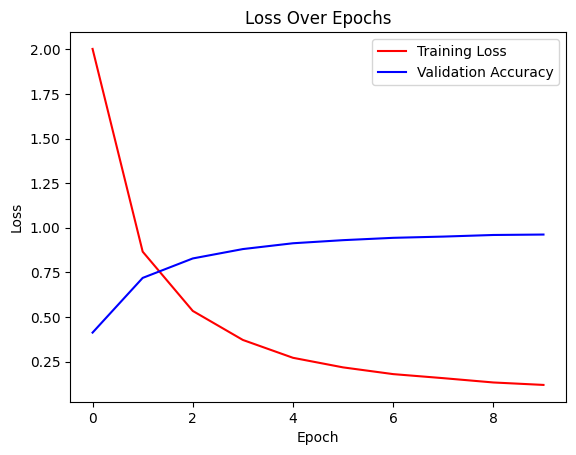

In [ ]:
plot_history(loss_history, accuracy_history)

In [ ]:
model.eval()
test_labels = []
test_preds = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        test_labels.append(labels.cpu())
        test_preds.append(predicted.cpu())

# Concatenate results
y_test_true = torch.cat(test_labels).numpy()
y_test_pred = torch.cat(test_preds).numpy()

# Generate and display the final report
test_report = calculate_metrics(y_test_true, y_test_pred, is_classification=True)
test_df = pd.DataFrame([test_report])
test_df.insert(0, "Dataset", "Official Test Set")

print(test_df)

             Dataset  Accuracy  Precision    Recall  F1-Score
0  Official Test Set  0.842122   0.856858  0.842122  0.843356


# Report

Our accuracy dropped to 84.2% primarily because of the data augmentation. It makes training much harder then what it sees on the test set. Its possible that the model overfitted by memorizing the specific pixel patterns in the augmented data.

The rotation shifts forced the model to learn the features as they varied rather then the static coordinates. This likely improved the model performance when faced with real world distorrion, but the simple 2-layer CNN lacks the amount of parameters to capture the variations in 10 epochs. The added noise was detrimaental to performance in the short term but we build a classifier that was more adaptable.